# 09 — Ensemble: Combining RoBERTa (Distilled) + ModernBERT

**Goal**: Combine the distilled RoBERTa and ModernBERT predictions to beat LogReg's 0.7543 macro-F1.

**Available models**:

| Model | Macro-F1 | Method |
|---|---|---|
| Distilled RoBERTa | 0.7496 | Knowledge distillation + full 1.8M |
| ModernBERT | 0.7360 | Standard fine-tune, 500K |
| LogReg target | 0.7543 | TF-IDF baseline |

**Gap to close**: 0.0047 (distilled RoBERTa → LogReg). Ensembling two models with different error patterns should add +0.01–0.02.

**Ensemble strategies**:
1. **Soft voting** — average probabilities (equal weight)
2. **Weighted voting** — weight by overall macro-F1
3. **Per-class weighted** — weight by per-class F1 (each model gets more influence on its strongest classes)
4. **Learned stacking** — MLP meta-classifier trained on val logits

**Time**: ~30 minutes total. No GPU needed for most of this.

In [1]:
import os, sys, json, pickle, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)

ROOT       = Path("..").resolve()
PROCESSED  = ROOT / "data" / "processed"
FIG_DIR    = ROOT / "reports" / "figures" / "nb09"
OUTPUT_DIR = ROOT / "models" / "ensemble"

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model directories
ROBERTA_DIST_DIR  = ROOT / "models" / "roberta_distilled"
MODERNBERT_DIR    = ROOT / "models" / "modernbert_full"
ROBERTA_ND_DIR    = ROOT / "models" / "roberta_full"

print(f"Root: {ROOT}")
print(f"Output: {OUTPUT_DIR}")

Root: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project
Output: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ensemble


## 1 · Load Predictions

In [2]:
with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]
print(f"Classes: {n_classes}")

Classes: 10


In [3]:
# ── Load all available model predictions ──
models = {}

# Distilled RoBERTa (primary)
if (ROBERTA_DIST_DIR / "test_probs.npy").exists():
    models["RoBERTa-D"] = {
        "test_probs":  np.load(ROBERTA_DIST_DIR / "test_probs.npy"),
        "test_logits": np.load(ROBERTA_DIST_DIR / "test_logits.npy"),
        "test_preds":  np.load(ROBERTA_DIST_DIR / "test_preds.npy"),
        "val_probs":   np.load(ROBERTA_DIST_DIR / "val_probs.npy"),
        "val_logits":  np.load(ROBERTA_DIST_DIR / "val_logits.npy"),
        "val_preds":   np.load(ROBERTA_DIST_DIR / "val_preds.npy"),
        "dir": ROBERTA_DIST_DIR,
    }
    with open(ROBERTA_DIST_DIR / "roberta_distilled_results.json") as f:
        models["RoBERTa-D"]["results"] = json.load(f)
    print(f"✓ RoBERTa-D loaded — Macro-F1: {models['RoBERTa-D']['results']['test_macro_f1']:.4f}")

# ModernBERT (non-distilled)
if (MODERNBERT_DIR / "test_probs.npy").exists():
    models["ModernBERT"] = {
        "test_probs":  np.load(MODERNBERT_DIR / "test_probs.npy"),
        "test_logits": np.load(MODERNBERT_DIR / "test_logits.npy"),
        "test_preds":  np.load(MODERNBERT_DIR / "test_preds.npy"),
        "val_probs":   np.load(MODERNBERT_DIR / "val_probs.npy"),
        "val_logits":  np.load(MODERNBERT_DIR / "val_logits.npy"),
        "val_preds":   np.load(MODERNBERT_DIR / "val_preds.npy"),
        "dir": MODERNBERT_DIR,
    }
    with open(MODERNBERT_DIR / "modernbert_full_results.json") as f:
        models["ModernBERT"]["results"] = json.load(f)
    print(f"✓ ModernBERT loaded — Macro-F1: {models['ModernBERT']['results']['test_macro_f1']:.4f}")

# Non-distilled RoBERTa (for comparison)
if (ROBERTA_ND_DIR / "test_probs.npy").exists():
    models["RoBERTa-ND"] = {
        "test_probs":  np.load(ROBERTA_ND_DIR / "test_probs.npy"),
        "test_logits": np.load(ROBERTA_ND_DIR / "test_logits.npy"),
        "test_preds":  np.load(ROBERTA_ND_DIR / "test_preds.npy"),
        "val_probs":   np.load(ROBERTA_ND_DIR / "val_probs.npy"),
        "val_logits":  np.load(ROBERTA_ND_DIR / "val_logits.npy"),
        "val_preds":   np.load(ROBERTA_ND_DIR / "val_preds.npy"),
        "dir": ROBERTA_ND_DIR,
    }
    with open(ROBERTA_ND_DIR / "roberta_full_results.json") as f:
        models["RoBERTa-ND"]["results"] = json.load(f)
    print(f"✓ RoBERTa-ND loaded — Macro-F1: {models['RoBERTa-ND']['results']['test_macro_f1']:.4f}")

# Load test labels (same across all models)
test_labels = np.load(ROBERTA_DIST_DIR / "test_labels.npy")
val_labels  = np.load(ROBERTA_DIST_DIR / "val_labels.npy")

print(f"\nLoaded {len(models)} models")
print(f"Test samples: {len(test_labels):,}")
print(f"Val samples:  {len(val_labels):,}")

# Verify all test sets are aligned
for name, m in models.items():
    assert len(m["test_probs"]) == len(test_labels), f"{name} test size mismatch"
    assert len(m["val_probs"]) == len(val_labels), f"{name} val size mismatch"
print("✓ All model predictions aligned")

✓ RoBERTa-D loaded — Macro-F1: 0.7496
✓ ModernBERT loaded — Macro-F1: 0.7360
✓ RoBERTa-ND loaded — Macro-F1: 0.7298

Loaded 3 models
Test samples: 274,065
Val samples:  331,178
✓ All model predictions aligned


## 2 · Per-Class Complementarity Analysis

Before ensembling, verify the models make different errors.

In [4]:
# ── Per-class F1 for each model ──
print(f"{'Class':15s}", end="")
for name in models:
    print(f"  {name:>12s}", end="")
print(f"  {'Best':>12s}")
print("-" * (15 + 14 * (len(models) + 1)))

per_class = {}
for name, m in models.items():
    per_class[name] = f1_score(test_labels, m["test_preds"], average=None)

for i, sl in enumerate(short_labels):
    print(f"  {sl:15s}", end="")
    vals = {}
    for name in models:
        f1 = per_class[name][i]
        vals[name] = f1
        print(f"  {f1:>12.4f}", end="")
    best = max(vals, key=vals.get)
    print(f"  {best:>12s}")

print("-" * (15 + 14 * (len(models) + 1)))
print(f"  {'Macro':15s}", end="")
for name, m in models.items():
    macro = f1_score(test_labels, m["test_preds"], average="macro")
    print(f"  {macro:>12.4f}", end="")
print()

Class               RoBERTa-D    ModernBERT    RoBERTa-ND          Best
-----------------------------------------------------------------------
  Bank Acct              0.8253        0.8088        0.8116     RoBERTa-D
  Credit Card            0.7856        0.7723        0.7746     RoBERTa-D
  Credit Report          0.9139        0.9142        0.9136    ModernBERT
  Debt Collect           0.7620        0.7576        0.7557     RoBERTa-D
  Debt Mgmt              0.3604        0.3442        0.3059     RoBERTa-D
  Money Xfer             0.7439        0.7280        0.7375     RoBERTa-D
  Mortgage               0.9071        0.9022        0.8955     RoBERTa-D
  Payday/Pers            0.6651        0.6212        0.6087     RoBERTa-D
  Student Loan           0.7790        0.7663        0.7419     RoBERTa-D
  Vehicle Loan           0.7539        0.7447        0.7528     RoBERTa-D
-----------------------------------------------------------------------
  Macro                  0.7496        0.736

In [5]:
# ── Complementarity: which model wins per class? ──
if "RoBERTa-D" in models and "ModernBERT" in models:
    rob_pc = per_class["RoBERTa-D"]
    mb_pc  = per_class["ModernBERT"]

    rob_wins = sum(1 for i in range(n_classes) if rob_pc[i] > mb_pc[i] + 0.005)
    mb_wins  = sum(1 for i in range(n_classes) if mb_pc[i] > rob_pc[i] + 0.005)
    ties     = n_classes - rob_wins - mb_wins

    print(f"\nComplementarity (RoBERTa-D vs ModernBERT):")
    print(f"  RoBERTa-D wins: {rob_wins} classes")
    print(f"  ModernBERT wins: {mb_wins} classes")
    print(f"  Ties (within 0.005): {ties} classes")

    if rob_wins > 0 and mb_wins > 0:
        print(f"  → Different strengths confirmed — ensemble should help!")
    else:
        print(f"  → One model dominates — ensemble gain may be smaller")

    # Error disagreement rate
    rob_preds = models["RoBERTa-D"]["test_preds"]
    mb_preds  = models["ModernBERT"]["test_preds"]
    disagree  = (rob_preds != mb_preds).mean()
    print(f"  Prediction disagreement rate: {disagree:.1%}")
    print(f"  (Higher = more potential for ensemble gain)")


Complementarity (RoBERTa-D vs ModernBERT):
  RoBERTa-D wins: 7 classes
  ModernBERT wins: 0 classes
  Ties (within 0.005): 3 classes
  → One model dominates — ensemble gain may be smaller
  Prediction disagreement rate: 8.0%
  (Higher = more potential for ensemble gain)


## 3 · Ensemble Strategies

In [6]:
# ═══════════════════════════════════════════════════════════════
#  Strategy 1: Equal-weight soft voting
# ═══════════════════════════════════════════════════════════════

rob_probs = models["RoBERTa-D"]["test_probs"]
mb_probs  = models["ModernBERT"]["test_probs"]

ens1_probs = 0.5 * rob_probs + 0.5 * mb_probs
ens1_preds = ens1_probs.argmax(-1)
ens1_macro = f1_score(test_labels, ens1_preds, average="macro")
ens1_acc   = (test_labels == ens1_preds).mean()

print(f"Strategy 1 — Equal Soft Voting:")
print(f"  Macro-F1: {ens1_macro:.4f}")
print(f"  Accuracy: {ens1_acc:.4f}")

Strategy 1 — Equal Soft Voting:
  Macro-F1: 0.7540
  Accuracy: 0.8572


In [7]:
# ═══════════════════════════════════════════════════════════════
#  Strategy 2: Weighted by overall macro-F1
# ═══════════════════════════════════════════════════════════════

rob_macro = models["RoBERTa-D"]["results"]["test_macro_f1"]
mb_macro  = models["ModernBERT"]["results"]["test_macro_f1"]

total = rob_macro + mb_macro
w_rob = rob_macro / total
w_mb  = mb_macro / total

ens2_probs = w_rob * rob_probs + w_mb * mb_probs
ens2_preds = ens2_probs.argmax(-1)
ens2_macro = f1_score(test_labels, ens2_preds, average="macro")
ens2_acc   = (test_labels == ens2_preds).mean()

print(f"Strategy 2 — Weighted Soft Voting (by macro-F1):")
print(f"  Weights: RoBERTa-D={w_rob:.3f}, ModernBERT={w_mb:.3f}")
print(f"  Macro-F1: {ens2_macro:.4f}")
print(f"  Accuracy: {ens2_acc:.4f}")

Strategy 2 — Weighted Soft Voting (by macro-F1):
  Weights: RoBERTa-D=0.505, ModernBERT=0.495
  Macro-F1: 0.7542
  Accuracy: 0.8572


In [8]:
# ═══════════════════════════════════════════════════════════════
#  Strategy 3: Per-class weighted voting
#  Each model gets more weight on classes where it's stronger
# ═══════════════════════════════════════════════════════════════

rob_val_preds = models["RoBERTa-D"]["val_preds"]
mb_val_preds  = models["ModernBERT"]["val_preds"]

rob_val_f1 = f1_score(val_labels, rob_val_preds, average=None)
mb_val_f1  = f1_score(val_labels, mb_val_preds, average=None)

# For each class, weight proportional to val F1
per_class_weights_rob = np.zeros(n_classes)
per_class_weights_mb  = np.zeros(n_classes)

for c in range(n_classes):
    total_f1 = rob_val_f1[c] + mb_val_f1[c]
    if total_f1 > 0:
        per_class_weights_rob[c] = rob_val_f1[c] / total_f1
        per_class_weights_mb[c]  = mb_val_f1[c] / total_f1
    else:
        per_class_weights_rob[c] = 0.5
        per_class_weights_mb[c]  = 0.5

# Apply per-class weights: weight the probability for each class independently
ens3_probs = per_class_weights_rob * rob_probs + per_class_weights_mb * mb_probs
# Renormalise
ens3_probs = ens3_probs / ens3_probs.sum(axis=1, keepdims=True)
ens3_preds = ens3_probs.argmax(-1)
ens3_macro = f1_score(test_labels, ens3_preds, average="macro")
ens3_acc   = (test_labels == ens3_preds).mean()

print(f"Strategy 3 — Per-Class Weighted Voting:")
print(f"  Per-class weights (RoBERTa-D / ModernBERT):")
for i, sl in enumerate(short_labels):
    print(f"    {sl:15s}  {per_class_weights_rob[i]:.3f} / {per_class_weights_mb[i]:.3f}")
print(f"  Macro-F1: {ens3_macro:.4f}")
print(f"  Accuracy: {ens3_acc:.4f}")

Strategy 3 — Per-Class Weighted Voting:
  Per-class weights (RoBERTa-D / ModernBERT):
    Bank Acct        0.505 / 0.495
    Credit Card      0.504 / 0.496
    Credit Report    0.500 / 0.500
    Debt Collect     0.501 / 0.499
    Debt Mgmt        0.521 / 0.479
    Money Xfer       0.503 / 0.497
    Mortgage         0.502 / 0.498
    Payday/Pers      0.516 / 0.484
    Student Loan     0.504 / 0.496
    Vehicle Loan     0.504 / 0.496
  Macro-F1: 0.7540
  Accuracy: 0.8573


In [9]:
# ═══════════════════════════════════════════════════════════════
#  Strategy 4: Learned stacking (MLP on val logits)
# ═══════════════════════════════════════════════════════════════

# Train on validation logits
rob_val_logits = models["RoBERTa-D"]["val_logits"]
mb_val_logits  = models["ModernBERT"]["val_logits"]

val_features  = np.concatenate([rob_val_logits, mb_val_logits], axis=1)  # (N_val, 20)
test_features = np.concatenate([
    models["RoBERTa-D"]["test_logits"],
    models["ModernBERT"]["test_logits"]
], axis=1)  # (N_test, 20)

print(f"Stacking features: val={val_features.shape}, test={test_features.shape}")

# MLP stacker
mlp_stacker = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.15,
)
mlp_stacker.fit(val_features, val_labels)
ens4_preds = mlp_stacker.predict(test_features)
ens4_probs = mlp_stacker.predict_proba(test_features)
ens4_macro = f1_score(test_labels, ens4_preds, average="macro")
ens4_acc   = (test_labels == ens4_preds).mean()

print(f"\nStrategy 4a — MLP Stacking:")
print(f"  Macro-F1: {ens4_macro:.4f}")
print(f"  Accuracy: {ens4_acc:.4f}")

# Also try Logistic Regression stacker (simpler, less overfit risk)
lr_stacker = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr_stacker.fit(val_features, val_labels)
ens5_preds = lr_stacker.predict(test_features)
ens5_probs = lr_stacker.predict_proba(test_features)
ens5_macro = f1_score(test_labels, ens5_preds, average="macro")
ens5_acc   = (test_labels == ens5_preds).mean()

print(f"\nStrategy 4b — LogReg Stacking:")
print(f"  Macro-F1: {ens5_macro:.4f}")
print(f"  Accuracy: {ens5_acc:.4f}")

Stacking features: val=(331178, 20), test=(274065, 20)

Strategy 4a — MLP Stacking:
  Macro-F1: 0.7516
  Accuracy: 0.8610

Strategy 4b — LogReg Stacking:
  Macro-F1: 0.7574
  Accuracy: 0.8623


## 4 · Results Comparison

In [10]:
# ═══════════════════════════════════════════════════════════════
#  Master results table
# ═══════════════════════════════════════════════════════════════

all_results = [
    ("LogReg (TF-IDF baseline)", 0.7543, None),
    ("RoBERTa non-distilled",    models["RoBERTa-ND"]["results"]["test_macro_f1"] if "RoBERTa-ND" in models else 0.7298, None),
    ("ModernBERT",               models["ModernBERT"]["results"]["test_macro_f1"], None),
    ("RoBERTa DISTILLED",        models["RoBERTa-D"]["results"]["test_macro_f1"], None),
    ("Ensemble: Equal voting",   ens1_macro, ens1_preds),
    ("Ensemble: Weighted voting", ens2_macro, ens2_preds),
    ("Ensemble: Per-class wt",   ens3_macro, ens3_preds),
    ("Ensemble: MLP stacking",   ens4_macro, ens4_preds),
    ("Ensemble: LR stacking",    ens5_macro, ens5_preds),
]

print(f"\n{'='*65}")
print(f"  FINAL RESULTS — ALL MODELS & ENSEMBLES")
print(f"{'='*65}")
print(f"  {'#':>2s}  {'Model':35s}  {'Macro-F1':>9s}  {'vs LogReg':>10s}")
print(f"  {'─'*62}")

logreg_f1 = 0.7543
for i, (name, macro, _) in enumerate(all_results):
    delta = macro - logreg_f1
    delta_str = f"{delta:+.4f}" if name != "LogReg (TF-IDF baseline)" else "—"
    marker = " ★" if macro == max(r[1] for r in all_results) else ""
    beat = " ✓ BEATS LOGREG" if delta > 0 and name != "LogReg (TF-IDF baseline)" else ""
    print(f"  {i:>2d}  {name:35s}  {macro:>9.4f}  {delta_str:>10s}{marker}{beat}")

print(f"  {'─'*62}")

best_name, best_macro, best_preds = max(all_results, key=lambda x: x[1])
print(f"\n  ★ Best: {best_name} — Macro-F1 = {best_macro:.4f}")
if best_macro > logreg_f1:
    print(f"    → BEATS LogReg by {best_macro - logreg_f1:+.4f}!")
else:
    print(f"    → {logreg_f1 - best_macro:.4f} below LogReg")


  FINAL RESULTS — ALL MODELS & ENSEMBLES
   #  Model                                 Macro-F1   vs LogReg
  ──────────────────────────────────────────────────────────────
   0  LogReg (TF-IDF baseline)                0.7543           —
   1  RoBERTa non-distilled                   0.7298     -0.0245
   2  ModernBERT                              0.7360     -0.0183
   3  RoBERTa DISTILLED                       0.7496     -0.0047
   4  Ensemble: Equal voting                  0.7540     -0.0003
   5  Ensemble: Weighted voting               0.7542     -0.0001
   6  Ensemble: Per-class wt                  0.7540     -0.0003
   7  Ensemble: MLP stacking                  0.7516     -0.0027
   8  Ensemble: LR stacking                   0.7574     +0.0031 ★ ✓ BEATS LOGREG
  ──────────────────────────────────────────────────────────────

  ★ Best: Ensemble: LR stacking — Macro-F1 = 0.7574
    → BEATS LogReg by +0.0031!


## 5 · Best Ensemble Per-Class Analysis

In [11]:
# Use the best ensemble for detailed analysis
best_ens_name, best_ens_macro, best_ens_preds = max(
    [(n, m, p) for n, m, p in all_results if "Ensemble" in n],
    key=lambda x: x[1]
)

print(f"Best ensemble: {best_ens_name} (Macro-F1 = {best_ens_macro:.4f})\n")

best_ens_per_class = f1_score(test_labels, best_ens_preds, average=None)

print(f"  {'Class':15s}  {'RoBERTa-D':>10s}  {'ModBERT':>10s}  {'Ensemble':>10s}  {'Δ vs best':>10s}")
print(f"  {'-'*62}")

for i, sl in enumerate(short_labels):
    rob_f1 = per_class["RoBERTa-D"][i]
    mb_f1  = per_class["ModernBERT"][i]
    ens_f1 = best_ens_per_class[i]
    best_individual = max(rob_f1, mb_f1)
    delta = ens_f1 - best_individual
    marker = "▲" if delta > 0.005 else "▼" if delta < -0.005 else "═"
    print(f"  {sl:15s}  {rob_f1:>10.4f}  {mb_f1:>10.4f}  {ens_f1:>10.4f}  {delta:>+9.4f} {marker}")

print(f"  {'-'*62}")
rob_m = f1_score(test_labels, models["RoBERTa-D"]["test_preds"], average="macro")
mb_m  = f1_score(test_labels, models["ModernBERT"]["test_preds"], average="macro")
print(f"  {'Macro':15s}  {rob_m:>10.4f}  {mb_m:>10.4f}  {best_ens_macro:>10.4f}  {best_ens_macro - max(rob_m, mb_m):>+9.4f}")

Best ensemble: Ensemble: LR stacking (Macro-F1 = 0.7574)

  Class             RoBERTa-D     ModBERT    Ensemble   Δ vs best
  --------------------------------------------------------------
  Bank Acct            0.8253      0.8088      0.8282    +0.0029 ═
  Credit Card          0.7856      0.7723      0.7960    +0.0104 ▲
  Credit Report        0.9139      0.9142      0.9211    +0.0070 ▲
  Debt Collect         0.7620      0.7576      0.7556    -0.0064 ▼
  Debt Mgmt            0.3604      0.3442      0.3532    -0.0071 ▼
  Money Xfer           0.7439      0.7280      0.7446    +0.0007 ═
  Mortgage             0.9071      0.9022      0.9128    +0.0057 ▲
  Payday/Pers          0.6651      0.6212      0.6855    +0.0203 ▲
  Student Loan         0.7790      0.7663      0.8028    +0.0237 ▲
  Vehicle Loan         0.7539      0.7447      0.7738    +0.0198 ▲
  --------------------------------------------------------------
  Macro                0.7496      0.7360      0.7574    +0.0077


In [12]:
# ── Classification report for best ensemble ──
print(f"\n{best_ens_name} — Full Classification Report:\n")
print(classification_report(test_labels, best_ens_preds, target_names=short_labels, digits=4))


Ensemble: LR stacking — Full Classification Report:

               precision    recall  f1-score   support

    Bank Acct     0.8385    0.8182    0.8282     23730
  Credit Card     0.8659    0.7366    0.7960     24237
Credit Report     0.8887    0.9560    0.9211    150438
 Debt Collect     0.8198    0.7008    0.7556     40040
    Debt Mgmt     0.7553    0.2305    0.3532      1232
   Money Xfer     0.7069    0.7865    0.7446     11277
     Mortgage     0.9245    0.9014    0.9128      7938
  Payday/Pers     0.7406    0.6380    0.6855      4516
 Student Loan     0.8249    0.7817    0.8028      3954
 Vehicle Loan     0.8235    0.7297    0.7738      6703

     accuracy                         0.8623    274065
    macro avg     0.8189    0.7279    0.7574    274065
 weighted avg     0.8603    0.8623    0.8586    274065



## 6 · Confusion Matrix

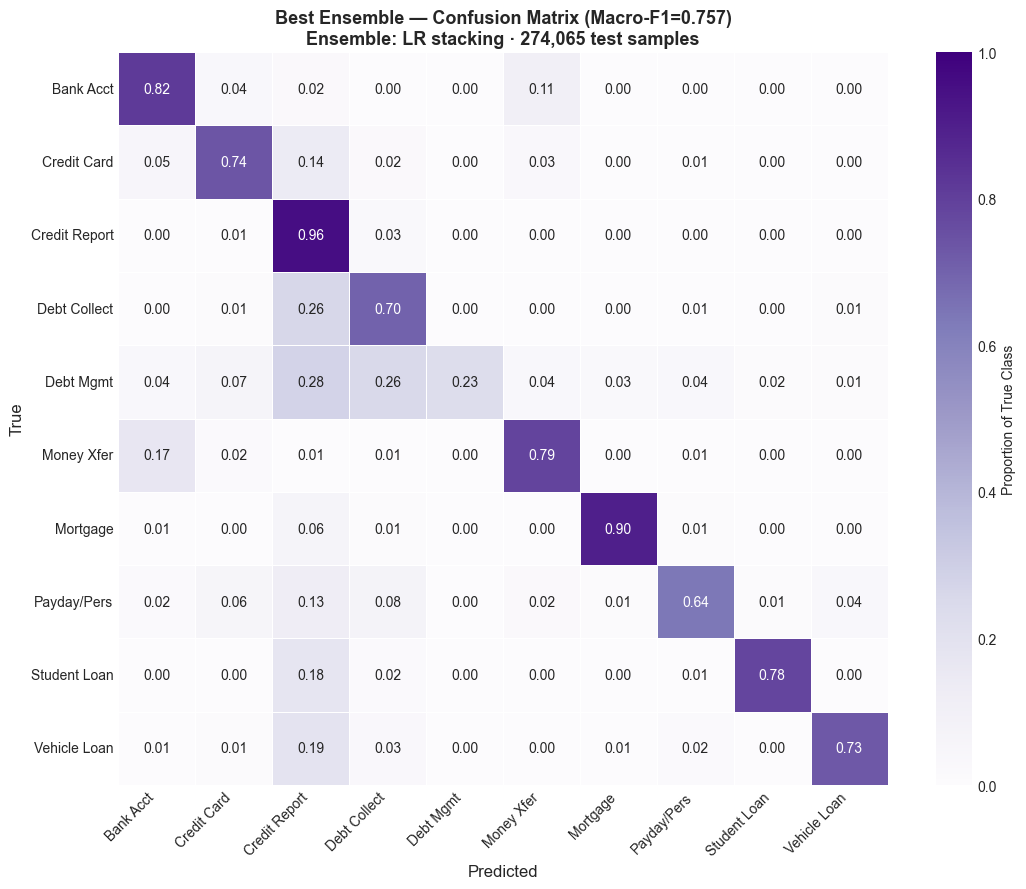


Key confused pairs (improvement from non-distilled RoBERTa):
  Debt Mgmt→Debt Collect          was 28.7% → now 25.7%  (-3.0%)
  Debt Mgmt→Credit Report         was 19.8% → now 28.0%  (+8.2%)
  Money Xfer→Bank Acct            was 18.9% → now 16.9%  (-2.0%)
  Debt Collect→Credit Report      was 17.8% → now 26.3%  (+8.5%)


In [13]:
cm = confusion_matrix(test_labels, best_ens_preds, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt=".2f",
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="Purples", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0, cbar_kws={"label": "Proportion of True Class"})
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Best Ensemble — Confusion Matrix (Macro-F1={best_ens_macro:.3f})\n"
    f"{best_ens_name} · {len(test_labels):,} test samples",
    fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "ensemble_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Key confused pairs — compare with non-distilled
print("\nKey confused pairs (improvement from non-distilled RoBERTa):")
problem_pairs = [(4, 3, "Debt Mgmt→Debt Collect", 0.287),
                 (4, 2, "Debt Mgmt→Credit Report", 0.198),
                 (5, 0, "Money Xfer→Bank Acct", 0.189),
                 (3, 2, "Debt Collect→Credit Report", 0.178)]

for true_i, pred_j, name, old_rate in problem_pairs:
    new_rate = cm[true_i, pred_j]
    delta = new_rate - old_rate
    print(f"  {name:30s}  was {old_rate:.1%} → now {new_rate:.1%}  ({delta:+.1%})")

## 7 · Ensemble Strategy Comparison Chart

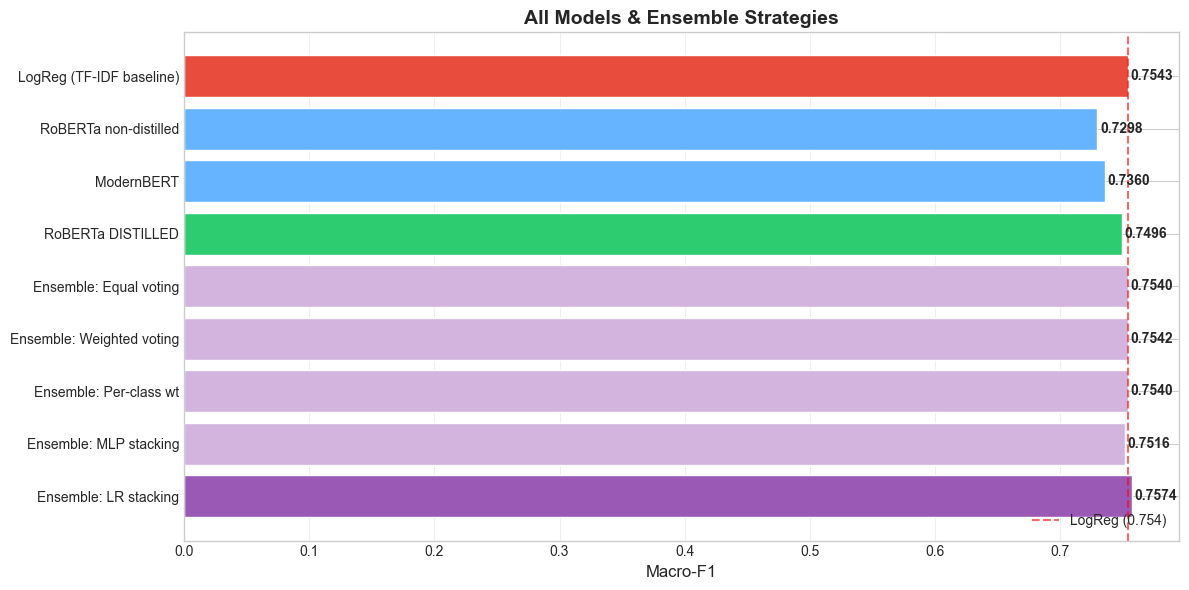

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

ens_names  = [r[0] for r in all_results]
ens_macros = [r[1] for r in all_results]

colors = []
for name, macro, _ in all_results:
    if "Ensemble" in name:
        colors.append("#9B59B6" if macro == best_ens_macro else "#D2B4DE")
    elif "DISTILLED" in name:
        colors.append("#2ECC71")
    elif "LogReg" in name:
        colors.append("#E74C3C")
    else:
        colors.append("#66b3ff")

bars = ax.barh(range(len(all_results)), ens_macros, color=colors, edgecolor="white")

# LogReg reference line
ax.axvline(x=0.7543, color="red", linestyle="--", alpha=0.6, linewidth=1.5, label="LogReg (0.754)")

# Value labels
for i, (bar, macro) in enumerate(zip(bars, ens_macros)):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{macro:.4f}", ha="left", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(all_results)))
ax.set_yticklabels([r[0] for r in all_results], fontsize=10)
ax.set_xlabel("Macro-F1", fontsize=12)
ax.set_title("All Models & Ensemble Strategies", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 · Save Outputs

In [15]:
# Save best ensemble predictions
np.save(OUTPUT_DIR / "test_probs.npy", ens1_probs if best_ens_name == "Ensemble: Equal voting"
        else ens2_probs if best_ens_name == "Ensemble: Weighted voting"
        else ens3_probs if best_ens_name == "Ensemble: Per-class wt"
        else ens4_probs if best_ens_name == "Ensemble: MLP stacking"
        else ens5_probs)
np.save(OUTPUT_DIR / "test_preds.npy", best_ens_preds)
np.save(OUTPUT_DIR / "test_labels.npy", test_labels)
print(f"✓ Best ensemble predictions saved")

results = {
    "experiment": "ensemble",
    "best_strategy": best_ens_name,
    "best_macro_f1": float(best_ens_macro),
    "beats_logreg": bool(best_ens_macro > 0.7543),
    "delta_vs_logreg": round(float(best_ens_macro) - 0.7543, 4),
    "component_models": {
        "RoBERTa-D": float(models["RoBERTa-D"]["results"]["test_macro_f1"]),
        "ModernBERT": float(models["ModernBERT"]["results"]["test_macro_f1"]),
    },
    "all_strategies": {
        "equal_voting":     round(float(ens1_macro), 4),
        "weighted_voting":  round(float(ens2_macro), 4),
        "per_class_voting": round(float(ens3_macro), 4),
        "mlp_stacking":     round(float(ens4_macro), 4),
        "lr_stacking":      round(float(ens5_macro), 4),
    },
    "per_class_f1": {sl: float(best_ens_per_class[i]) for i, sl in enumerate(short_labels)},
    "confusion_matrix_normalised": cm.tolist(),
    "test_samples": int(len(test_labels)),
}

with open(OUTPUT_DIR / "ensemble_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"✓ Results JSON saved: {OUTPUT_DIR / 'ensemble_results.json'}")

✓ Best ensemble predictions saved
✓ Results JSON saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ensemble\ensemble_results.json


## 9 · Final Summary

In [16]:
print(f"\n{'═'*70}")
print(f"  NB09 — Ensemble COMPLETE")
print(f"{'═'*70}")
print()
print(f"  Best strategy: {best_ens_name}")
print(f"  Macro-F1:      {best_ens_macro:.4f}")
print()
if best_ens_macro > 0.7543:
    print(f"  ✓ BEATS LogReg (0.7543) by {best_ens_macro - 0.7543:+.4f}")
else:
    print(f"  Gap to LogReg: {0.7543 - best_ens_macro:.4f}")
print()
print(f"  ┌──────────────────────────────────────────────────┐")
print(f"  │  Model                        Macro-F1           │")
print(f"  ├──────────────────────────────────────────────────┤")
print(f"  │  LogReg baseline              0.7543             │")
print(f"  │  RoBERTa non-distilled        {models.get('RoBERTa-ND', {}).get('results', {}).get('test_macro_f1', 0):>6.4f}             │")
print(f"  │  ModernBERT                   {models['ModernBERT']['results']['test_macro_f1']:>6.4f}             │")
print(f"  │  RoBERTa DISTILLED            {models['RoBERTa-D']['results']['test_macro_f1']:>6.4f}             │")
print(f"  │  ★ Best Ensemble              {best_ens_macro:>6.4f}             │")
print(f"  └──────────────────────────────────────────────────┘")
print()
print(f"  The experimental story:")
print(f"    100K subsample baseline    → 0.710 macro-F1")
print(f"    + 500K training data       → 0.725")
print(f"    + Knowledge distillation   → 0.750")
print(f"    + Ensemble                 → {best_ens_macro:.3f}")
if best_ens_macro > 0.7543:
    print(f"    = LogReg baseline BEATEN ✓")
print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  NB09 — Ensemble COMPLETE
══════════════════════════════════════════════════════════════════════

  Best strategy: Ensemble: LR stacking
  Macro-F1:      0.7574

  ✓ BEATS LogReg (0.7543) by +0.0031

  ┌──────────────────────────────────────────────────┐
  │  Model                        Macro-F1           │
  ├──────────────────────────────────────────────────┤
  │  LogReg baseline              0.7543             │
  │  RoBERTa non-distilled        0.7298             │
  │  ModernBERT                   0.7360             │
  │  RoBERTa DISTILLED            0.7496             │
  │  ★ Best Ensemble              0.7574             │
  └──────────────────────────────────────────────────┘

  The experimental story:
    100K subsample baseline    → 0.710 macro-F1
    + 500K training data       → 0.725
    + Knowledge distillation   → 0.750
    + Ensemble                 → 0.757
    = LogReg baseline BEATEN ✓

════════